#  Support Vector Machines (SVM): Comprehensive Guide & Implementation

Welcome to the **Support Vector Machines (SVM)** module. SVM is a powerful, highly accurate supervised machine learning algorithm primarily used for **Classification** tasks, though it can also handle regression (SVR).

---

### 1. What is SVM?

Unlike Logistic Regression which calculates output probabilities, SVM focuses on finding the **optimal boundary (Hyperplane)** that separates different classes with the maximum possible safe distance.

* **Hyperplane:** The decision boundary that splits the data classes (a line in 2D, a flat plane in 3D, and a hyperplane in higher dimensions).
* **Support Vectors:** The critical data points closest to the boundary. The entire mathematical model depends solely on these points; removing them would shift the hyperplane.
* **Margin:** The empty distance between the hyperplane and the support vectors. SVM's primary goal is to **maximize this margin**.

---

### 2. Hard Margin vs. Soft Margin

When dealing with separating boundaries, SVM handles data noise using two margin approaches:

### A. Hard Margin
* **Definition:** Enforces a strict rule that data must be 100% linearly separable with **zero misclassifications**.
* **Drawback:** Real-world data contains noise and outliers. A single outlier can cause Hard Margin to fail or create a tiny margin, leading to severe **overfitting**.

### B. Soft Margin
* **Definition:** Allows a controlled amount of error or misclassification to achieve a better, more generalized boundary.
* **Hyperparameter ($C$):** 
  * **High $C$:** Penalizes errors heavily (behaves like a Hard Margin).
  * **Low $C$:** Allows more misclassifications for a wider, safer margin.

---

## 3. The Kernel Trick (Handling Non-Linear Data)

Real-world data is rarely separable by a simple straight line (e.g., circular or nested clusters). 

* **The Kernel Function:** A mathematical shortcut that projects lower-dimensional data (like 2D) into a **higher-dimensional space** (like 3D) where a flat hyperplane can cleanly separate it.
* **The Kernel Trick:** Computes this high-dimensional relationship without actually performing the heavy computational cost of transforming every coordinate explicitly.

---

## 4. Linear vs. Non-Linear Kernels

* **Linear Kernel (`kernel='linear'`):**
  * Used when data is already linearly separable. 
  * Extremely fast and ideal for high-dimensional datasets (e.g., text classification).
* **Polynomial Kernel (`kernel='poly'`):**
  * Uses polynomial equations to build curved, loop-based boundaries.
* **RBF Kernel (`kernel='radial basis function'`):**
  * The most popular and powerful non-linear kernel.
  * Can map data into infinite dimensions to handle complex, circular, or cluster-based patterns.

---



# Import Liberaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR,LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score,confusion_matrix, classification_report,ConfusionMatrixDisplay

In [3]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_20952\1530099147.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


,id,old_order_id,increment_id,status,channel_name,is_guest,customer_email,customer_first_name,customer_last_name,shipping_method,...,additional,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
0,1,NaN,ORD-00000001,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,ORD-00000002,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,ORD-00000003,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,ORD-00000004,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,ORD-00000005,closed,Cartlow UAE,0,imranishaq87@gmail.com,Imran,NaN,flatrate_flatrate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


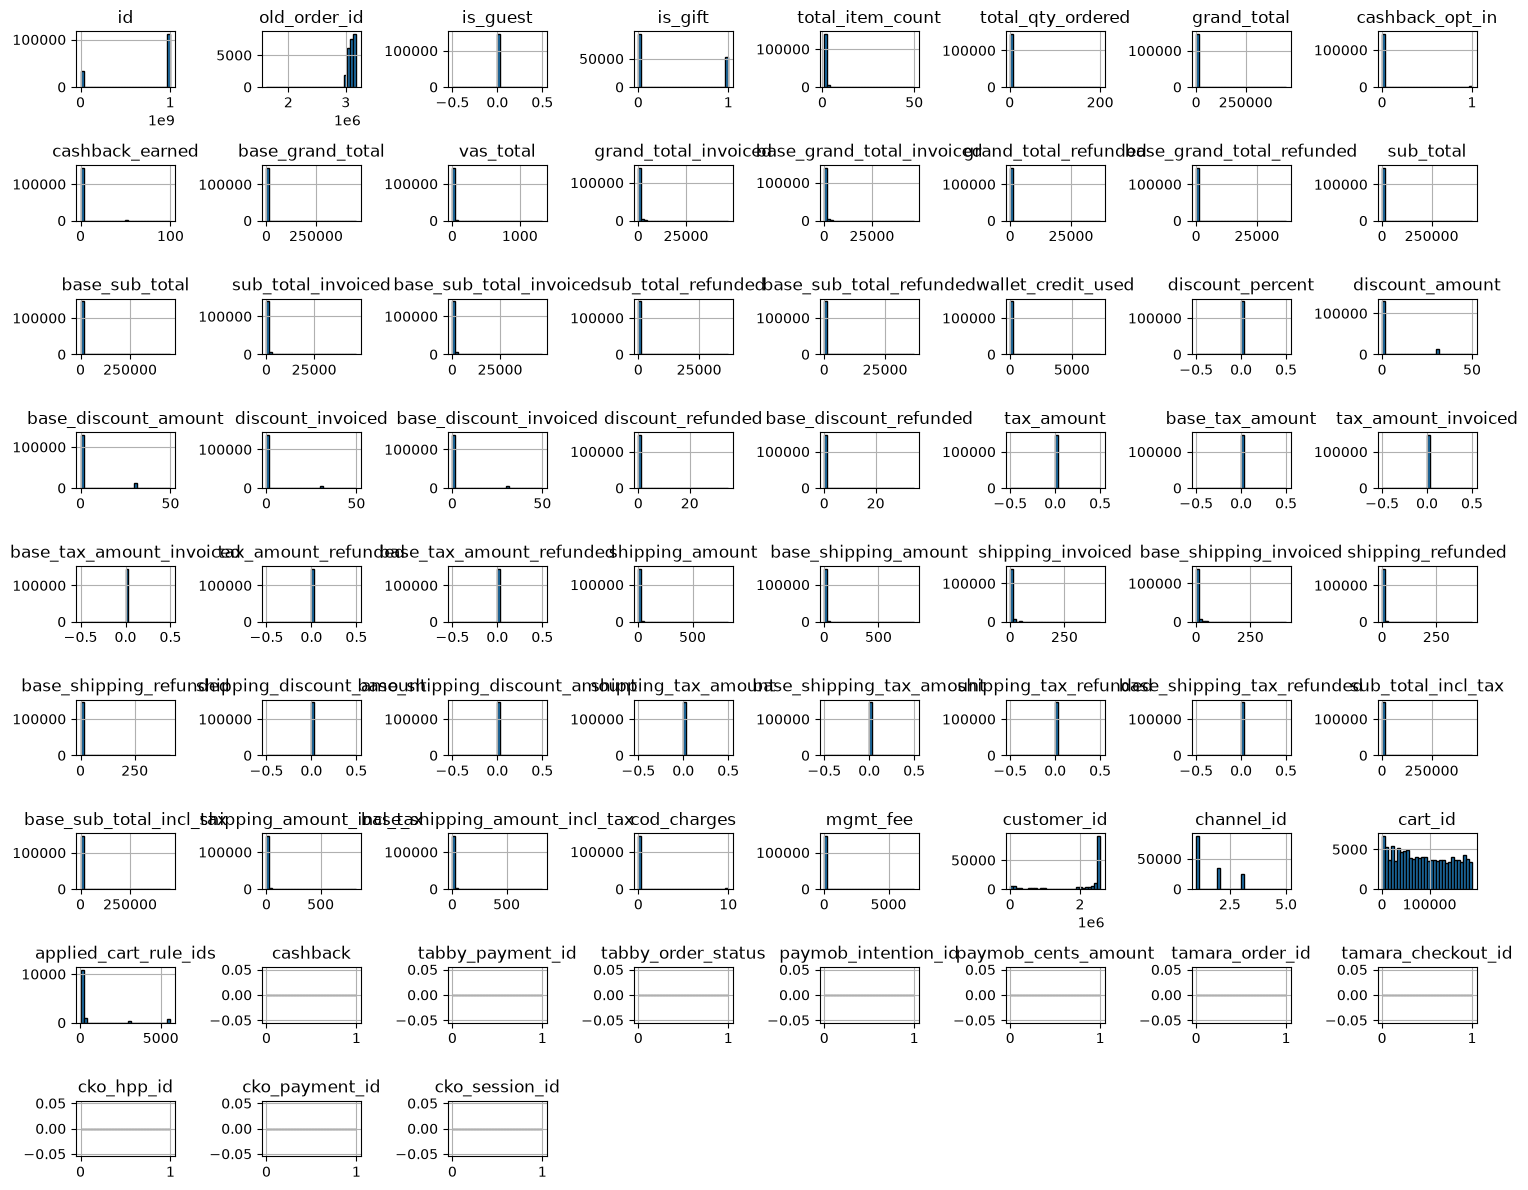

In [4]:
df.hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.tight_layout()  

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 146201 entries, 0 to 146200
Data columns (total 85 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             146201 non-null  int64  
 1   old_order_id                   23913 non-null   float64
 2   increment_id                   146201 non-null  str    
 3   status                         146201 non-null  str    
 4   channel_name                   146201 non-null  str    
 5   is_guest                       146201 non-null  int64  
 6   customer_email                 134010 non-null  str    
 7   customer_first_name            136057 non-null  str    
 8   customer_last_name             74428 non-null   str    
 9   shipping_method                75149 non-null   str    
 10  shipping_title                 75149 non-null   str    
 11  shipping_description           75149 non-null   str    
 12  coupon_code                    13444 non-

In [6]:
df.describe()

,id,old_order_id,is_guest,is_gift,total_item_count,total_qty_ordered,grand_total,cashback_opt_in,cashback_earned,base_grand_total,...,cashback,tabby_payment_id,tabby_order_status,paymob_intention_id,paymob_cents_amount,tamara_order_id,tamara_checkout_id,cko_hpp_id,cko_payment_id,cko_session_id
count,1.462010e+05,2.391300e+04,146201.0,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,146201.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,7.668132e+08,3.104356e+06,0.0,0.359512,1.222481,1.397713,1123.514495,0.020725,0.307358,1126.128750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.257860e+08,5.378918e+04,0.0,0.479859,0.825899,1.778782,2207.205445,0.142462,3.762055,2207.333091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,1.618874e+06,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.003187e+09,3.067517e+06,0.0,0.000000,1.000000,1.000000,135.500000,0.000000,0.000000,138.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.003224e+09,3.109158e+06,0.0,0.000000,1.000000,1.000000,552.000000,0.000000,0.000000,556.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.003262e+09,3.146486e+06,0.0,1.000000,1.000000,1.000000,1612.000000,0.000000,0.000000,1612.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.003299e+09,3.184983e+06,0.0,1.000000,50.000000,200.000000,454000.000000,1.000000,100.000000,454000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data preprocessing

In [7]:
print(". Starting Data Preparation...")
useless_cols = [
    'cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 
    'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 
    'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 
    'shipping_title', 'shipping_description', 'coupon_code', 'created_at', 'updated_at'
]
df_clean = df.drop(columns=[col for col in useless_cols if col in df.columns])
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

. Starting Data Preparation...
Shape after removing duplicates: (146201, 85)


### Feature Engineering

In [8]:
print(" Performing Feature Engineering...")
df_clean['discount_ratio'] = df_clean['discount_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['tax_ratio'] = df_clean['tax_amount'] / (df_clean['sub_total'] + 1e-5)
df_clean['shipping_ratio'] = df_clean['shipping_amount'] / (df_clean['grand_total'] + 1e-5)
df_clean['avg_item_price'] = df_clean['sub_total'] / (df_clean['total_qty_ordered'] + 1e-5)
print("New engineered features added successfully!")

 Performing Feature Engineering...
New engineered features added successfully!


### Define Target Variable (y): Let's predict if an order is 'completed' (0) vs 'canceled/other' (1)


In [9]:
df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)
print("Class Distribution in Target:")
print(df_clean['target'].value_counts())

Class Distribution in Target:
target
1    99975
0    46226
Name: count, dtype: int64


In [10]:
core_features = [
    # Numerical Financials & Quantities
    'sub_total', 'discount_amount', 'tax_amount', 'shipping_amount', 
    'cod_charges', 'wallet_credit_used', 'total_item_count', 
    'total_qty_ordered', 'cashback_earned', 'mgmt_fee',
    # Categorical (Low cardinality)
    'channel_name', 'customer_type', 'shipping_method',
    # Flags (0/1)
    'is_guest', 'is_gift', 'cashback_opt_in'
]

available_features = [col for col in core_features if col in df_clean.columns]
X_raw = df_clean[available_features].copy()
y = df_clean['target']





### Handle Missing Values (Imputation)


In [11]:
num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())
cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

print(f"Missing values handled. Features shape: {X_raw.shape}")

Missing values handled. Features shape: (146201, 16)


### Feature Encoding (One-Hot Encoding)


In [12]:
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)
print(f"Encoded Feature matrix shape (X): {X.shape}")

Encoded Feature matrix shape (X): (146201, 19)


### Train-Test Split 


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling 



In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaling completed successfully!")

Data split and scaling completed successfully!


### Model training

In [15]:
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_scaled, y_train, train_size=30000, stratify=y_train, random_state=42
)

rbf_fast = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
rbf_fast.fit(X_train_sub, y_train_sub)
print("Model trained successfully!")


Model trained successfully!


### Model Evaluation on Test Set




In [16]:
y_pred_rbf = rbf_fast.predict(X_test_scaled)

print("\n" + "=" * 50)
print(" CLASSIFICATION PERFORMANCE BENCHMARK ")
print("=" * 50)
print(f"Accuracy Score : {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred_rbf):.4f}")
print(f"Recall Score   : {recall_score(y_test, y_pred_rbf):.4f}")
print(f"F1 Score       : {f1_score(y_test, y_pred_rbf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))
print("=" * 50)



 CLASSIFICATION PERFORMANCE BENCHMARK 
Accuracy Score : 0.7387
Precision Score: 0.8489
Recall Score   : 0.7517
F1 Score       : 0.7973

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.71      0.63      9247
           1       0.85      0.75      0.80     19994

    accuracy                           0.74     29241
   macro avg       0.71      0.73      0.71     29241
weighted avg       0.76      0.74      0.75     29241



### Live Test / Single Sample Simulation


In [18]:

from sklearn.calibration import CalibratedClassifierCV

base_svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
rbf_live = CalibratedClassifierCV(estimator=base_svm, method='sigmoid')
rbf_live.fit(X_train_sub, y_train_sub)

sample_index = 0
single_sample_scaled = X_test_scaled[sample_index:sample_index+1]
true_label = y_test.iloc[sample_index]

predicted_class = rbf_live.predict(single_sample_scaled)[0]
prediction_probabilities = rbf_live.predict_proba(single_sample_scaled)[0]

print(f"True Status: {true_label}")
print(f"Predicted Class: {predicted_class}")
print(f"Probability of Class 0 (Completed): {prediction_probabilities[0]*100:.2f}%")
print(f"Probability of Class 1 (Other): {prediction_probabilities[1]*100:.2f}%")

True Status: 1
Predicted Class: 1
Probability of Class 0 (Completed): 13.28%
Probability of Class 1 (Other): 86.72%


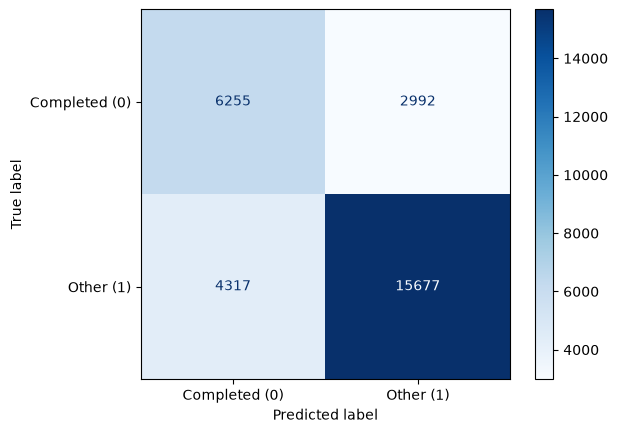

In [21]:
y_pred_all = rbf_live.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_all)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Completed (0)', 'Other (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [22]:
import pickle
pickle.dump(rbf_live, open("saved_models/rbf_svm_model.pkl", "wb"))